# **Modelado — Store Item Demand Forecasting Challenge**

## Objetivo

Entrenar y evaluar un modelo de regresión (**LightGBM**) para predecir la demanda diaria (`sales`) de cada combinación `store` x `item`, usando como insumo el dataset ya limpio y con features de calendario generado en `01-data_transformation.ipynb` y explorado en `02-eda.ipynb`.

## Contenido del notebook

1. **Carga de datos** — lectura de `train_final.csv` y `test_final.csv`.
2. **Feature engineering temporal** — lags y medias/desviaciones móviles de ventas, y partición train/validación respetando el orden cronológico (sin fuga de información hacia el futuro).
3. **Entrenamiento LightGBM** — ajuste del modelo con *early stopping* sobre el set de validación.
4. **Evaluación** — métricas de regresión estándar (RMSE, MAE, R²) y métricas propias de forecasting de demanda (SMAPE, WAPE, RMSLE).
5. **Diagnóstico** — gráficos de residuos, error por tienda/mes e importancia de variables.
6. **Modelo final y submission** — reentrenamiento con el 100% del histórico y generación recursiva (día a día) de las predicciones para el set de test.
7. **Próximos pasos** — espacio reservado para comparar contra XGBoost y CatBoost.

## Resultado obtenido

Con la configuración documentada más abajo, el modelo LightGBM alcanza en el set de validación (últimos ~12 meses del histórico, no vistos en entrenamiento):

| Métrica | Train | Validación |
|---|---|---|
| RMSE | 7.56 | 8.36 |
| MAE | 5.83 | 6.44 |
| WAPE % | 11.44 | 10.89 |
| SMAPE % (métrica oficial del challenge) | 13.38 | 12.63 |
| R² | 0.926 | 0.930 |

La diferencia pequeña entre train y validación indica que el modelo generaliza bien y no presenta sobreajuste relevante.

In [ ]:
# --- Manejo de datos ---
import pandas as pd
import numpy as np
from pathlib import Path

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# LightGBM emite warnings informativos (p. ej. sobre columnas categóricas)
# que no aportan valor en este notebook; se silencian para mantener la salida limpia.
import warnings
warnings.filterwarnings('ignore')

# --- Módulos propios del proyecto (src/), para no duplicar feature engineering,
#     hiperparámetros ni métricas entre notebook y scripts/ ---
import sys
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.build_features import create_lag_features, create_rolling_features, FEATURES, TARGET
from src.evaluation.metrics import regression_report, evaluate_metrics
from src.models.train_model import get_model, CATEGORICAL_FEATURES
from src.models.predict import recursive_predict

## 1. Carga de datos

Se cargan los datasets ya procesados en `01-data_transformation.ipynb`:

- `train_final.csv`: histórico de ventas por `store` / `item` / `date`, usado para entrenar y validar.
- `test_final.csv`: combinaciones `store` / `item` / `date` a predecir (sin la columna `sales`), correspondientes al set de test del challenge.

La columna `date` se convierte explícitamente a `datetime` porque es la base de todo el feature engineering temporal (lags, rolling stats, orden cronológico del split).

In [121]:
# Rutas absolutas a los datasets finales generados en el notebook de transformación de datos
ruta_train = Path("../data/3.final/train_final.csv").resolve()
ruta_test = Path("../data/3.final/test_final.csv").resolve()

df_train = pd.read_csv(ruta_train, sep=',')
df_test = pd.read_csv(ruta_test, sep=',')

# Parseo explícito de fechas: necesario para poder ordenar cronológicamente
# y calcular features basados en el tiempo (lags, rolling stats, día/mes/semana).
df_train['date'] = pd.to_datetime(df_train['date'], format='%Y-%m-%d')
df_test['date'] = pd.to_datetime(df_test['date'], format='%Y-%m-%d')

## 2. Feature engineering temporal y split train/validación

Se construyen **variables de lag** (ventas de 7, 14, 21 y 28 días atrás) y **estadísticos móviles** (media y desviación estándar sobre ventanas de 7 días de historia, desplazadas 7 días) por cada combinación `store`/`item`, usando `create_lag_features` / `create_rolling_features` de [`src/features/build_features.py`](../src/features/build_features.py) — las mismas funciones que usan `scripts/train.py` y `scripts/predict.py`, para que el notebook y el pipeline de producción no diverjan. Estas variables capturan estacionalidad semanal y tendencia reciente, que son las señales más fuertes para predecir demanda.

Puntos clave de la implementación:

- **Orden estricto por `store`, `item`, `date`** antes de calcular los lags (lo hace la propia función): `groupby().shift()` depende de que las filas estén ordenadas cronológicamente dentro de cada grupo, de lo contrario el lag quedaría mal calculado.
- **`shift(7)` antes del `rolling`**: evita que el estadístico móvil use información del día que se quiere predecir (fuga de información / *data leakage*).
- **`dropna` sobre `lag_28`**: al ser el lag más largo, elimina automáticamente las filas iniciales de cada serie que no tienen suficiente historia para ningún lag (7, 14, 21 o 28).
- **Split 80/20 por fecha (no aleatorio)**: en series de tiempo, un split aleatorio filtraría información del futuro hacia el entrenamiento. Se ordena por `date` y se separa el último 20% como validación, simulando el escenario real de producción (predecir el futuro con datos del pasado).

> **Nota:** `rolling_mean_7_28` y `rolling_std_7_28` se calculan pero no forman parte del set final de `FEATURES` (importado de `build_features.py`) usado para entrenar — quedan disponibles en el DataFrame para experimentación futura.

In [ ]:
# 1-2. Lags y rolling stats (implementación en src/features/build_features.py,
#    compartida con scripts/train.py y scripts/predict.py). Ambas funciones
#    ordenan internamente por (store, item, date) antes de calcular los shift.
df_train = create_lag_features(df_train, lags=[7, 14, 21, 28])
df_train = create_rolling_features(df_train, windows=[7, 14, 28], shift=7)

# 3. Se descartan las filas sin suficiente historia. Basta con exigir lag_28
#    (el lag más largo) porque implica que lag_7, lag_14 y lag_21 también existen.
df_train = df_train.dropna(subset=['lag_28', 'rolling_mean_7_28']).reset_index(drop=True)

# 4. Split temporal 80/20 por fecha (no aleatorio): el 20% más reciente se usa como validación,
#    replicando el escenario real de predecir el futuro con datos del pasado.
df_train = df_train.sort_values('date').reset_index(drop=True)

split_idx = int(len(df_train) * 0.8)
train_df = df_train.iloc[:split_idx].copy()
valid_df = df_train.iloc[split_idx:].copy()

# FEATURES y TARGET importados de src.features.build_features (mismo set validado)
X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_valid = valid_df[FEATURES]
y_valid = valid_df[TARGET]
df_valid = valid_df.copy()

print(f"Train: {train_df['date'].min().date()} -> {train_df['date'].max().date()} | {len(train_df)}")
print(f"Valid: {valid_df['date'].min().date()} -> {valid_df['date'].max().date()} | {len(valid_df)}")
print(f"NaN en valid: {X_valid.isna().sum().sum()}")  # debe ser 0: confirma que no quedaron huecos en los features

## 3. LightGBM Regressor

Se entrena un modelo **LightGBM** (`lgb.train`, API nativa) para predecir `sales` a partir de las variables de calendario y de lag definidas arriba.

**Configuración del entrenamiento:**

| Parámetro | Valor | Motivo |
|---|---|---|
| `objective` | `regression` | Minimiza error cuadrático (L2), apropiado para un target continuo como `sales`. |
| `metric` | `rmse` | Métrica de monitoreo para early stopping. |
| `learning_rate` | `0.05` | Tasa de aprendizaje conservadora, compensada con `num_boost_round` alto + early stopping. |
| `num_leaves` | `64` | Controla la complejidad de cada árbol; balance entre capacidad y sobreajuste. |
| `feature_fraction` | `0.8` | Cada árbol usa el 80% de las columnas (submuestreo de features, reduce varianza). |
| `bagging_fraction` / `bagging_freq` | `0.8` / `5` | Cada 5 iteraciones se re-muestrea el 80% de las filas (submuestreo de datos, reduce varianza). |
| `store`, `item` | `categorical_feature` | Se declaran explícitamente como categóricas para que LightGBM las trate por *splits* óptimos en vez de como variables numéricas continuas. |

**Early stopping:** se entrena hasta `num_boost_round=2000`, pero se detiene automáticamente si el RMSE de validación no mejora en 100 rondas consecutivas (`lgb.early_stopping(100)`), quedándose con el mejor árbol encontrado. Esto evita tener que elegir manualmente el número de iteraciones y protege contra sobreajuste.

In [ ]:
import lightgbm as lgb

# Datasets nativos de LightGBM. `store` e `item` se marcan como categóricas.
train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_FEATURES)
valid_set = lgb.Dataset(X_valid, label=y_valid, reference=train_set)

# Hiperparámetros centralizados en src/models/train_model.py (compartidos con scripts/)
params = get_model('lgb')

model = lgb.train(
    params,
    train_set,
    valid_sets=[valid_set],
    num_boost_round=2000,
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
)

# Predicciones del modelo (con el mejor número de árboles según early stopping)
# sobre el set de validación, para evaluar el desempeño más adelante.
df_valid['pred'] = model.predict(X_valid)

**Resultado del entrenamiento:** el early stopping se activó en la iteración **339** (de 2000 posibles), con un **RMSE de validación de 8.359**. Esto confirma que las 2000 rondas configuradas eran más que suficientes y que el modelo converge razonablemente rápido con estos hiperparámetros.

## 4. Evaluación del modelo

Además del RMSE usado internamente por LightGBM, se calculan métricas adicionales más interpretables para un problema de forecasting de demanda:

- **MAE**: error absoluto promedio, en las mismas unidades que `sales`.
- **RMSLE**: penaliza más los errores relativos en ventas bajas; robusto a outliers de ventas altas.
- **MAPE / SMAPE**: error porcentual. **SMAPE es la métrica oficial de evaluación del Store Item Demand Forecasting Challenge**.
- **WAPE**: error porcentual ponderado por volumen (más robusto que MAPE cuando hay ventas cercanas a 0).
- **R²**: proporción de la varianza de `sales` explicada por el modelo.
- **BIAS**: `mean(pred - real)`. Negativo = el modelo subestima en promedio; positivo = sobreestima.

In [ ]:
# smape, rmsle, regression_report y evaluate_metrics viven en src/evaluation/metrics.py
# (importadas en la celda de imports), para reutilizarlas también desde scripts/evaluate.py.

# Reporte comparativo train vs. validación
regression_report(y_train, model.predict(X_train), "Train")
regression_report(y_valid, model.predict(X_valid), "Valid")

**Lectura de resultados:**

| Métrica | Train | Validación |
|---|---|---|
| RMSE | 7.559 | 8.359 |
| MAE | 5.830 | 6.440 |
| RMSLE | 0.172 | 0.162 |
| MAPE % | 14.101 | 13.202 |
| SMAPE % | 13.383 | 12.628 |
| WAPE % | 11.437 | 10.894 |
| R² | 0.926 | 0.930 |
| BIAS | 0.000 | -0.052 |

- El desempeño en validación es prácticamente igual (incluso ligeramente mejor) al de train, lo que indica **buena capacidad de generalización** y ausencia de sobreajuste significativo.
- **SMAPE de validación ≈ 12.6%**, la métrica oficial del challenge.
- **BIAS de validación ≈ -0.05**: el modelo subestima muy levemente la demanda en promedio, un sesgo prácticamente despreciable en la escala de `sales`.

## 5. Diagnóstico visual

Se generan cuatro tipos de gráficos para validar visualmente el comportamiento del modelo más allá de las métricas agregadas:

1. **Serie real vs. predicha en el tiempo**: detecta si el modelo pierde tendencia o estacionalidad en algún tramo.
2. **Dispersión real vs. predicho**: si los puntos se "abren" respecto a la diagonal, el modelo pierde precisión en rangos altos/bajos de ventas.
3. **Residuos vs. predicción**: una nube sin forma indica errores homogéneos; un patrón (embudo, curva) indica que el modelo falla sistemáticamente en cierto rango.
4. **Distribución de residuos**: debe estar centrada cerca de 0 y ser aproximadamente simétrica.

También se descompone el error (MAE) por tienda y por mes, y se revisa la importancia de variables para confirmar que los lags de ventas son las señales dominantes.

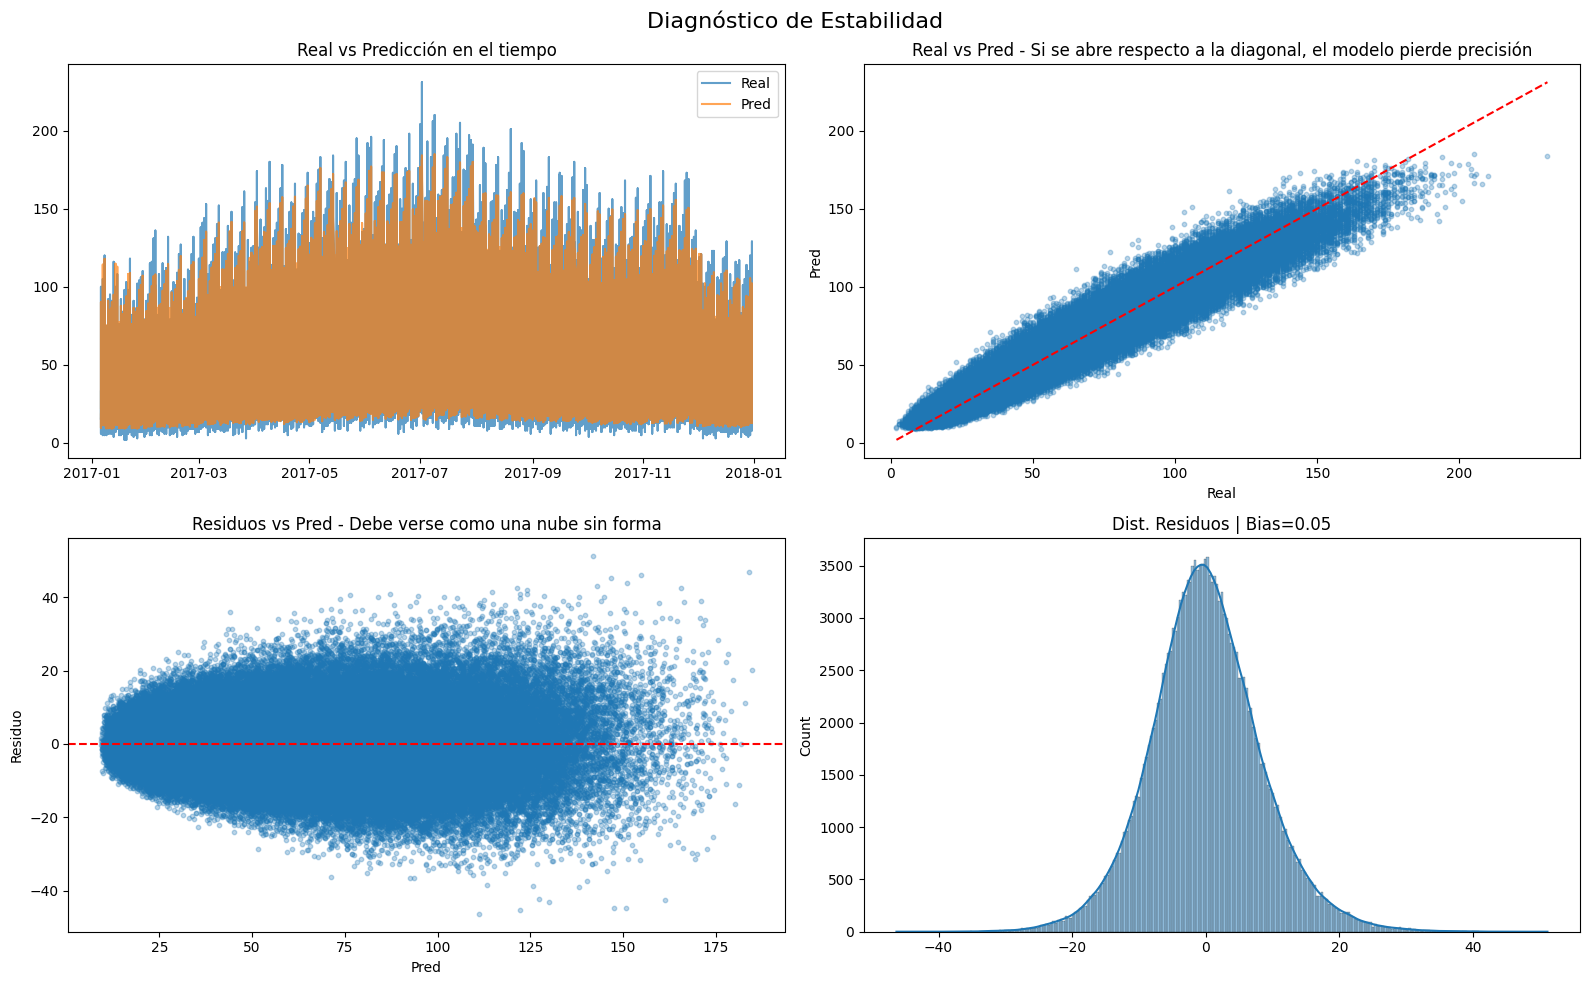

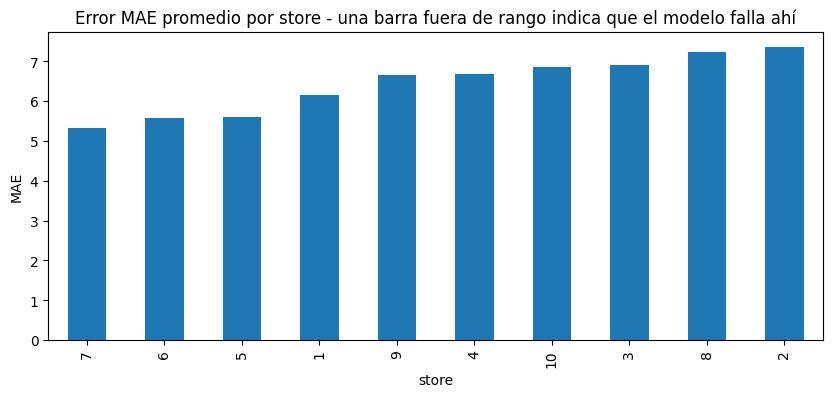

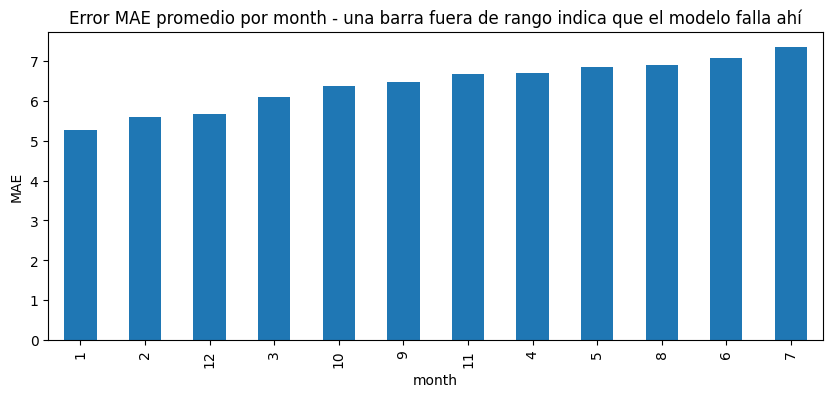

El modelo no expone `feature_importances_` (usa model.feature_importance() para un Booster de lgb.train)


In [125]:
def plot_all_diagnostics(df_valid, y_true_col='sales', y_pred_col='pred', date_col='date'):
    """Grilla 2x2 con los diagnósticos estándar de un modelo de regresión/forecasting:
    serie temporal real vs. predicha, dispersión real vs. predicha, residuos vs. predicción
    y distribución de residuos."""
    y_true = df_valid[y_true_col]
    y_pred = df_valid[y_pred_col]
    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Diagnóstico de Estabilidad", fontsize=16)

    # 1. Real vs. predicho a lo largo del tiempo
    axes[0, 0].plot(df_valid[date_col], y_true, label='Real', alpha=0.7)
    axes[0, 0].plot(df_valid[date_col], y_pred, label='Pred', alpha=0.7)
    axes[0, 0].set_title("Real vs Predicción en el tiempo")
    axes[0, 0].legend()

    # 2. Dispersión real vs. predicho (referencia: diagonal y=x)
    axes[0, 1].scatter(y_true, y_pred, alpha=0.3, s=10)
    axes[0, 1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axes[0, 1].set_title("Real vs Pred - Si se abre respecto a la diagonal, el modelo pierde precisión")
    axes[0, 1].set_xlabel("Real"); axes[0, 1].set_ylabel("Pred")

    # 3. Residuos vs. predicción (busca patrones sistemáticos de error)
    axes[1, 0].scatter(y_pred, residuals, alpha=0.3, s=10)
    axes[1, 0].axhline(0, color='r', linestyle='--')
    axes[1, 0].set_title("Residuos vs Pred - Debe verse como una nube sin forma")
    axes[1, 0].set_xlabel("Pred"); axes[1, 0].set_ylabel("Residuo")

    # 4. Distribución de residuos (idealmente centrada en 0 y simétrica)
    sns.histplot(residuals, kde=True, ax=axes[1, 1])
    axes[1, 1].set_title(f"Dist. Residuos | Bias={residuals.mean():.2f}")

    plt.tight_layout()
    plt.show()


def plot_error_by_group(df_valid, group_col='store', y_true='sales', y_pred='pred'):
    """Barra de MAE promedio agrupado por `group_col` (p. ej. store o month),
    para detectar segmentos donde el modelo falla más que el promedio."""
    df_valid['abs_error'] = np.abs(df_valid[y_true] - df_valid[y_pred])
    error_by = df_valid.groupby(group_col)['abs_error'].mean().sort_values()

    plt.figure(figsize=(10, 4))
    error_by.plot(kind='bar')
    plt.title(f"Error MAE promedio por {group_col} - una barra fuera de rango indica que el modelo falla ahí")
    plt.ylabel("MAE")
    plt.show()


def plot_feature_importance(model, feature_names):
    """Top 15 variables por importancia (compatible con modelos sklearn-like:
    LightGBM/XGBoost/CatBoost con atributo `feature_importances_`)."""
    try:
        imp = pd.DataFrame({
            'feature': feature_names,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False).head(15)

        plt.figure(figsize=(8, 5))
        sns.barplot(data=imp, x='importance', y='feature')
        plt.title("Top Features - is_weekend y los lags deberían estar arriba")
        plt.show()
    except AttributeError:
        print("El modelo no expone `feature_importances_` (usa model.feature_importance() para un Booster de lgb.train)")


plot_all_diagnostics(df_valid)
plot_error_by_group(df_valid, 'store')
plot_error_by_group(df_valid, 'month')
plot_feature_importance(model, FEATURES)

## 6. Ajuste de sesgo (bias correction)

Se prueba una corrección aditiva fija (`-1.0149`) sobre las predicciones de validación, y se recalcula la importancia de variables directamente desde el `Booster` (`model.feature_importance(importance_type='gain')`), que es la forma correcta de obtenerla cuando se entrena con `lgb.train` (a diferencia de `feature_importances_`, propio de la API sklearn).

> ⚠️ **Observación:** el valor `-1.0149` no coincide con el `BIAS` medido en la sección 4 para este modelo (`-0.052`). Aplicar esta corrección tal cual empeoraría el sesgo actual en vez de corregirlo. Probablemente quedó de una iteración anterior del feature engineering. Se documenta el código tal como está, pero **se recomienda recalcular el bias correction con el valor de `BIAS` medido arriba (o retirar este paso) antes de usarlo en producción.**

         Valid corregido
RMSE               8.427
MAE                6.475
RMSLE              0.162
MAPE %            12.930
SMAPE %           12.723
WAPE %            10.954
R2                 0.929
BIAS              -1.067
              feature    importance
10              lag_7  2.396753e+09
14   rolling_mean_7_7  5.821650e+08
15  rolling_mean_7_14  4.869346e+08
11             lag_14  3.454923e+08
12             lag_21  1.760564e+08
13             lag_28  1.080519e+08
3               month  5.382272e+07
4                week  3.245589e+07
5          is_weekend  2.873010e+07
2                 day  1.954232e+07
1                item  6.768241e+06
8    days_since_start  2.639497e+06
0               store  2.111955e+06
9         is_year_end  6.254830e+05
7        is_month_end  7.378166e+04


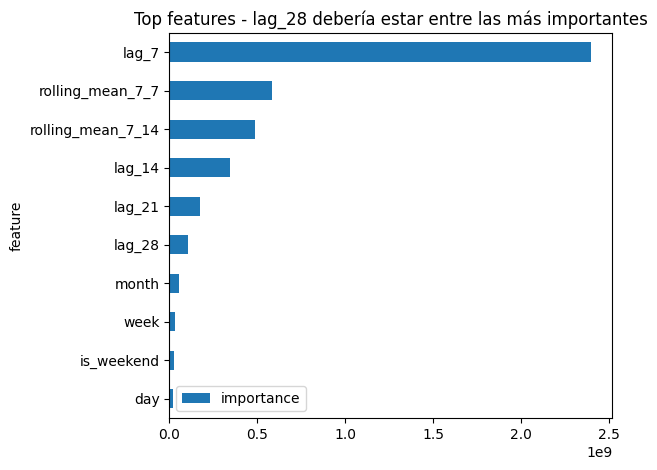

In [126]:
# Corrección de sesgo: desplaza las predicciones por una constante fija medida previamente.
# Ver observación en la celda de arriba sobre la validez de este valor con el modelo actual.
df_valid['pred_final'] = df_valid['pred'] - 1.0149
regression_report(df_valid['sales'], df_valid['pred_final'], "Valid corregido")

# Importancia de variables por ganancia ('gain'), más informativa que por número
# de splits ('split') porque pondera cuánto reduce cada variable el error del modelo.
importance = pd.DataFrame({
    'feature': model.feature_name(),
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print(importance.head(15).to_string())

importance.head(10).sort_values('importance').plot(kind='barh', x='feature', y='importance')
plt.title("Top features - lag_28 debería estar entre las más importantes")
plt.tight_layout()
plt.show()

## 7. Modelo final y predicción recursiva sobre el test

> Esta sección ilustra el pipeline completo con **LightGBM** (el modelo con el que se prototipó originalmente). El modelo que realmente se usa en producción es el ganador documentado en [`docs/model_selection.md`](../docs/model_selection.md) — actualmente **CatBoost** — y se entrena/predice con `scripts/train.py` + `scripts/predict.py` (que reutilizan exactamente la misma lógica de `src/features/build_features.py` y `src/models/predict.py` que esta celda).

Para generar la submission se siguen tres ideas centrales:

1. **Re-estimar `num_boost_round` para el 100% de los datos.** El early stopping de la sección 3 encontró 339 como óptimo, pero usando solo el 80% del histórico (train). Con más datos es esperable necesitar más árboles, así que en vez de asumir un número fijo sin validar, se separa un **hold-out temporal del 12% más reciente** del histórico completo (`df_train_full`) exclusivamente para medir el `best_iteration` con early stopping — el mismo criterio de la sección 3, aplicado ahora sobre el dataset completo.
2. **Reentrenar con el 100% del histórico** usando el `num_boost_round` así validado: una vez encontrado ese número de árboles, se descarta el hold-out y se reentrena con todas las filas disponibles (incluido ese 12%), para que el modelo que efectivamente predice el test no pierda datos recientes.
3. **Predicción recursiva (walk-forward), día por día** (`recursive_predict` en `src/models/predict.py`): el set de test no trae `sales`, pero los features `lag_7`, `lag_14`, etc. de sus primeros días dependen de ventas reales de diciembre de 2017 (train), y las de los días siguientes dependen de **predicciones previas del propio modelo**. Por eso se concatena `train + test` en un único DataFrame (`df_all`) y, para cada fecha de test, se recalculan lags/rolling con el historial acumulado hasta ese momento antes de predecir — así una predicción del día 29 sí puede depender de la predicción del día 1, no de un lag relleno con 0.

> **Nota:** una alternativa más rápida a la re-estimación con hold-out (sin entrenar un modelo de sondeo adicional) es aproximar `num_boost_round ≈ best_iteration_80% * 1.2` (≈ 407 en este caso). Se optó por el hold-out por ser más riguroso: usa el criterio real de early stopping sobre el dataset completo en vez de un multiplicador heurístico, a costa de un entrenamiento extra.

In [ ]:
# --- 1. Recalcular features de lag/rolling sobre el histórico COMPLETO ---
# (mismas funciones de src/features/build_features.py que en la sección 2;
# df_train ya viene ordenado y con calendario desde data/3.final/train_final.csv)
df_train_full = create_lag_features(df_train, lags=[7, 14, 21, 28])
df_train_full = create_rolling_features(df_train_full, windows=[7, 14], shift=7, include_std_window=None)
df_train_full = df_train_full.dropna(subset=['lag_28', 'rolling_mean_7_14']).reset_index(drop=True)

X_full = df_train_full[FEATURES]
y_full = df_train_full[TARGET]

# Hiperparámetros centralizados en src/models/train_model.py (compartidos con scripts/)
params = get_model('lgb')

# --- 2. Re-estimar num_boost_round sobre el 100% de los datos ---
# Hold-out temporal del 12% más reciente, usado SOLO para encontrar el best_iteration
# con el mismo criterio de early stopping de la sección 3 (no para evaluar el modelo final).
FINAL_HOLDOUT_FRAC = 0.12
final_split_idx = int(len(df_train_full) * (1 - FINAL_HOLDOUT_FRAC))

X_full_fit, y_full_fit = X_full.iloc[:final_split_idx], y_full.iloc[:final_split_idx]
X_full_holdout, y_full_holdout = X_full.iloc[final_split_idx:], y_full.iloc[final_split_idx:]

full_fit_set = lgb.Dataset(X_full_fit, label=y_full_fit, categorical_feature=CATEGORICAL_FEATURES)
full_holdout_set = lgb.Dataset(X_full_holdout, label=y_full_holdout, reference=full_fit_set)

model_probe = lgb.train(
    params,
    full_fit_set,
    valid_sets=[full_holdout_set],
    num_boost_round=2000,
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)]
)

best_iteration_full = model_probe.best_iteration
print(f"best_iteration (80% del histórico, sección 3):        339")
print(f"best_iteration (100% del histórico, hold-out {FINAL_HOLDOUT_FRAC:.0%}): {best_iteration_full}")

# --- 3. Reentrenar el modelo final con el 100% del histórico y el num_boost_round validado ---
train_full_set = lgb.Dataset(X_full, label=y_full, categorical_feature=CATEGORICAL_FEATURES)
model_final = lgb.train(params, train_full_set, num_boost_round=best_iteration_full)

# --- 4. Concatenar train + test para poder calcular lags de forma continua ---
# (df_test ya trae sus columnas de calendario desde data/3.final/test_final.csv)
# Así el lag_7 del primer día de test toma la venta real de una semana antes (dic-2017, train).
df_all = pd.concat([
    df_train_full[['store', 'item', 'date', 'sales']],
    df_test[['store', 'item', 'date']].assign(sales=np.nan)  # test aún no tiene sales
], ignore_index=True).sort_values(['store', 'item', 'date']).reset_index(drop=True)
df_all['sales'] = df_all['sales'].astype(float)  # fuerza float; si no, el rolling falla con NaN mixtos

# --- 5. Predicción recursiva (walk-forward), implementada en src/models/predict.py ---
# A diferencia del prototipo original (que calculaba los lags UNA sola vez antes del loop,
# dejando en 0 -por el fillna- los lags de los días de test más allá de ~28 días), esta
# versión recalcula lag/rolling en cada iteración con el historial ya acumulado (train real
# + predicciones ya hechas), así el walk-forward es real. Ver docstring de recursive_predict.
df_all = recursive_predict(model_final, df_all, df_test['date'].unique(), FEATURES)

# --- 6. Submission: solo las filas correspondientes a las fechas de test ---
df_submission_lgb = df_all[df_all['date'].isin(df_test['date'])][['store', 'item', 'date', 'sales']]

## 8. Guardado de la submission

Se exporta `df_submission_lgb` (columnas `store`, `item`, `date`, `sales`) a `data/3.final/submission_lgb.csv`.

> Esta es la submission del prototipo LightGBM de esta sección. La submission "oficial" del modelo ganador (`docs/model_selection.md`) se genera con `python scripts/predict.py` → `data/3.final/submission_best.csv`.

In [ ]:
ruta_submision = Path("../data/3.final/submission_lgb.csv").resolve()
df_submission_lgb.to_csv(ruta_submision, index=False)

## **XGBoostRegressor** — mismo split, mismas métricas

Se entrena `xgboost.XGBRegressor` sobre el mismo `X_train`/`y_train` y se valida sobre el mismo `X_valid`/`y_valid` usados por LightGBM, para que la comparación entre modelos sea directa (mismas filas, mismos `FEATURES`, mismo `TARGET`).

Hiperparámetros elegidos como análogos razonables a los usados en LightGBM (`learning_rate=0.05`, profundidad acotada, submuestreo de filas/columnas) más `early_stopping_rounds=100` sobre el set de validación, igual que el `lgb.early_stopping(100)` de la sección 3.

In [ ]:
# Hiperparámetros centralizados en src/models/train_model.py (compartidos con scripts/)
xgb_model = get_model('xgb', early_stopping_rounds=100)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# Predicciones sobre el mismo set de validación que LightGBM, para comparar en igualdad de condiciones
df_valid['pred_xgb'] = xgb_model.predict(X_valid)

xgb_metrics = regression_report(y_valid, df_valid['pred_xgb'], "XGBoost")
print(xgb_metrics)

## **CatBoostRegressor** — mismo split, mismas métricas

Se entrena `catboost.CatBoostRegressor` sobre el mismo `X_train`/`y_train` y se valida sobre el mismo `X_valid`/`y_valid` de las secciones anteriores. `store` e `item` se declaran como `cat_features`, igual que se marcaron como `categorical_feature` en LightGBM, para que CatBoost las trate de forma nativa en vez de asumirlas numéricas.

`early_stopping_rounds=100` sobre el set de validación mantiene el mismo criterio de parada que LightGBM y XGBoost.

In [ ]:
# Hiperparámetros centralizados en src/models/train_model.py (compartidos con scripts/)
cat_model = get_model('catboost', early_stopping_rounds=100)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    cat_features=CATEGORICAL_FEATURES
)

# Predicciones sobre el mismo set de validación que LightGBM y XGBoost
df_valid['pred_cat'] = cat_model.predict(X_valid)

cat_metrics = regression_report(y_valid, df_valid['pred_cat'], "CatBoost")
print(cat_metrics)

## Comparativa final LightGBM vs XGBoost vs CatBoost

Se reúnen las métricas de validación de los tres modelos (mismo `X_valid`/`y_valid`) en una sola tabla, ordenada por **WAPE %** ascendente — la métrica de error porcentual ponderado por volumen, más robusta que MAPE para este dataset (hay combinaciones store/item con ventas bajas donde MAPE se distorsiona).

> El análisis completo del resultado (incluyendo el matiz sobre BIAS) queda documentado en [`docs/model_selection.md`](../docs/model_selection.md), que es la fuente de verdad que usa `scripts/train.py` para decidir qué modelo entrenar en producción.

In [133]:
# df_valid['pred'] ya fue calculado por el modelo LightGBM de la sección 3
lgb_metrics = regression_report(y_valid, df_valid['pred'], "LightGBM")

model_comparison = pd.DataFrame(
    [lgb_metrics, xgb_metrics, cat_metrics],
    index=['LightGBM', 'XGBoost', 'CatBoost']
).sort_values('WAPE %', ascending=True)

model_comparison

         LightGBM
RMSE        8.359
MAE         6.440
RMSLE       0.162
MAPE %     13.202
SMAPE %    12.628
WAPE %     10.894
R2          0.930
BIAS       -0.052


,RMSE,MAE,RMSLE,MAPE %,SMAPE %,WAPE %,R2,BIAS
CatBoost,8.309525,6.398409,0.161538,13.086374,12.563046,10.823847,0.930860,-0.416518
LightGBM,8.359492,6.440120,0.162425,13.201609,12.628024,10.894407,0.930026,-0.052487
XGBoost,8.392242,6.458679,0.162670,13.190817,12.662539,10.925801,0.929477,-0.207218
